# Global Monsoon

The classic definition is that "local summer" should have 55% of rainfall, and 2 mm/day more rainfall than "local winter". How we define these is another question...

## Imports etc

In [1]:
import os
import sys
import datetime as dt
import cmocean as cmo

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import haversine, hp_mods, get_nn_lon_lat_index

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/franmorr/.conda/envs/hk26_env/share/proj failed


In [2]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
# sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=5, time='PT1H').to_dask().pipe(hp_mods)
pr = ds.pr*3600*24
pr["units"]="mm day-1"

## Difference testing
Specifically for DJFM and JJAS.

Text(0.5, 1.0, 'Local summer - local winter\ndaily mean rainfall difference\nis greater than 2mm/day')

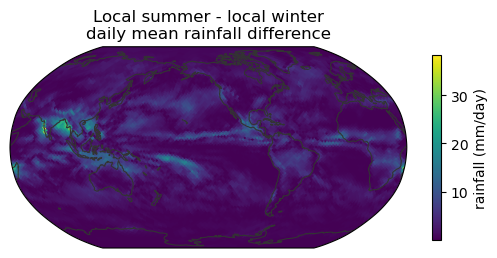

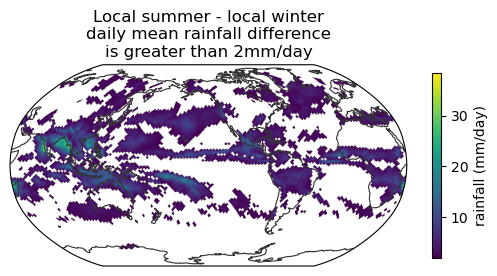

In [4]:
DJFM = pr.sel(time=slice("2020-12-01", "2021-03-31")).mean(dim="time")
JJAS = pr.sel(time=slice("2020-06-01", "2020-09-30")).mean(dim="time")
diff = abs(DJFM - JJAS)
im = egh.healpix_show(diff)
plt.colorbar(im, label="rainfall (mm/day)", shrink=0.5)
plt.title("Local summer - local winter\ndaily mean rainfall difference")
plt.figure()
im = egh.healpix_show(diff.where(diff > 2))
plt.colorbar(im, label="rainfall (mm/day)", shrink=0.5)
plt.title(
    "Local summer - local winter\ndaily mean rainfall difference\nis greater than 2mm/day"
)

Text(0.5, 1.0, 'Local summer mean rainfall')

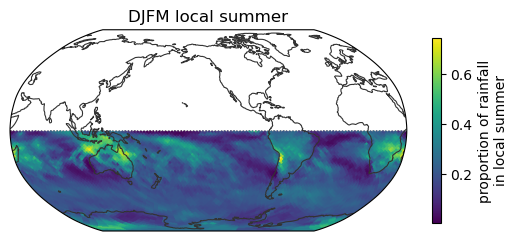

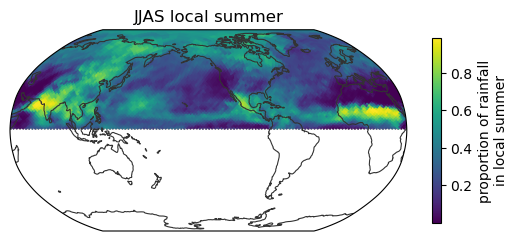

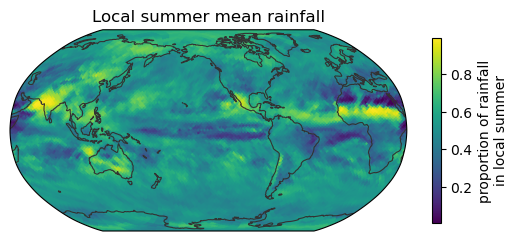

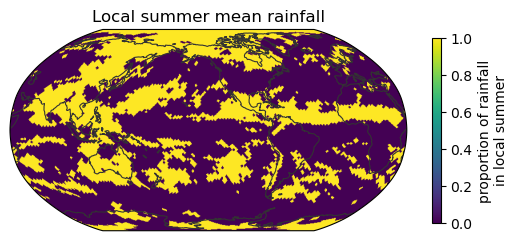

In [5]:
djfm_summer = (DJFM - JJAS) > 0
djfm_summer = (DJFM.lat) < 0
annual_sum_djfm_summer = pr[:, djfm_summer.values].sum(dim="time")
djfm_sum_djfm_summer = pr.sel(time=slice("2020-12-01", "2021-03-31")).sum(dim="time")
plt.figure()
im = egh.healpix_show(djfm_sum_djfm_summer / annual_sum_djfm_summer)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("DJFM local summer")

jjas_summer = (JJAS - DJFM) > 0
jjas_summer = (JJAS.lat) > 0

annual_sum_jjas_summer = pr[:, jjas_summer.values].sum(dim="time")
jjas_sum_jjas_summer = pr.sel(time=slice("2020-06-01", "2020-09-30")).sum(dim="time")
plt.figure()
im = egh.healpix_show(jjas_sum_jjas_summer / annual_sum_jjas_summer)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("JJAS local summer")

annual_sum=pr.sum(dim="time")
all_sum_local_summer = djfm_sum_djfm_summer+jjas_sum_jjas_summer
plt.figure()
im = egh.healpix_show(all_sum_local_summer / annual_sum)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("Local summer mean rainfall")

plt.figure()
im = egh.healpix_show(all_sum_local_summer / annual_sum > 0.55)
plt.colorbar(im, label="proportion of rainfall\nin local summer", shrink=0.5)
plt.title("Local summer mean rainfall")

In [6]:
def get_proportion(pr, DJFM=None, JJAS=None, proportion=0.55, localsummer="lat"):
    if DJFM == None:
        DJFM = pr.sel(time=slice("2020-12-01", "2021-03-31")).mean(dim="time")
    if JJAS == None:
        JJAS = pr.sel(time=slice("2020-06-01", "2020-09-30")).mean(dim="time")
    
    if localsummer == "lat":
        jjas_summer = JJAS.lat > 0
        djfm_summer = DJFM.lat < 0
    elif localsummer=="rain":
        jjas_summer = (JJAS - DJFM) > 0
        djfm_summer = (DJFM - JJAS) > 0
    annual_sum_djfm_summer = pr[:, djfm_summer.values].sum(dim="time")
    djfm_sum_djfm_summer = pr.sel(time=slice("2020-12-01", "2021-03-31")).sum(
        dim="time"
    )
    annual_sum_jjas_summer = pr[:, jjas_summer.values].sum(dim="time")
    jjas_sum_jjas_summer = pr.sel(time=slice("2020-06-01", "2020-09-30")).sum(
        dim="time"
    )
    annual_sum = pr.sum(dim="time")
    all_sum_local_summer = djfm_sum_djfm_summer + jjas_sum_jjas_summer
    proportion_local_summer = all_sum_local_summer / annual_sum
    return proportion_local_summer

def restrict_proportion(pr, DJFM=None, JJAS=None, proportion=0.55):
    proportion_local_summer=get_proportion(pr, DJFM=DJFM, JJAS=JJAS, proportion=proportion)
    restricted_by_proportion = proportion_local_summer > proportion
    return restricted_by_proportion


def get_diff(pr, DJFM=None, JJAS=None, lim=2):
    if DJFM == None:
        DJFM = pr.sel(time=slice("2020-12-01", "2021-03-31")).mean(dim="time")
    if JJAS == None:
        JJAS = pr.sel(time=slice("2020-06-01", "2020-09-30")).mean(dim="time")
    diff = abs(DJFM - JJAS)
    return diff

def restrict_diff(pr, DJFM=None, JJAS=None, lim=2):
    diff=get_diff(pr, DJFM=DJFM, JJAS=JJAS, lim=lim)
    return diff > lim

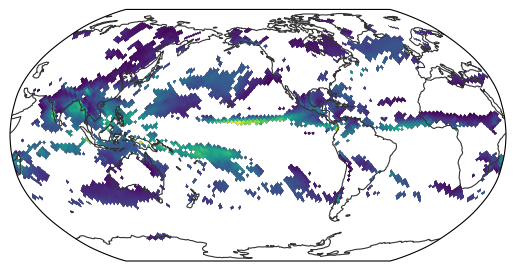

In [15]:
egh.healpix_show(
    pr.mean(dim="time")[
        (restrict_proportion(pr, proportion=0.5) & restrict_diff(pr, lim=2)).values
    ]
)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


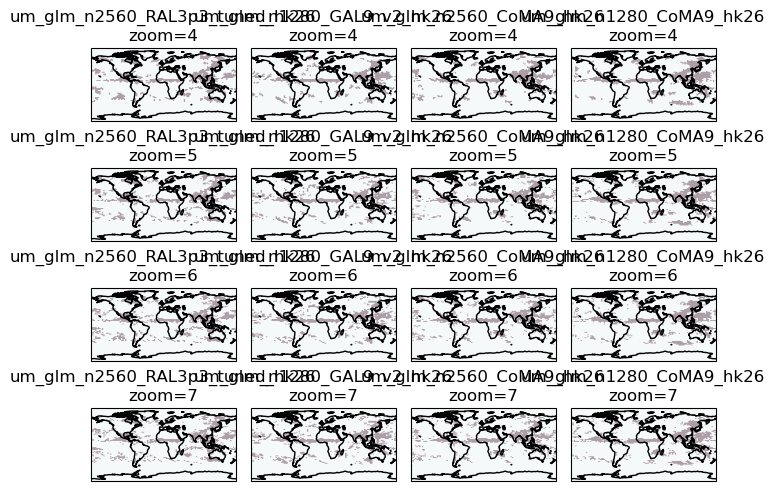

In [17]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [4, 5, 6, 7]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    len(zooms),
    len(sims),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes[zoom_ix, sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3)

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr) & restrict_diff(pr),
            resampler=hp_resampler,
            ax=ax,
            alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}\nzoom={zoom}")
#         ().plot.contour(ax=ax)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


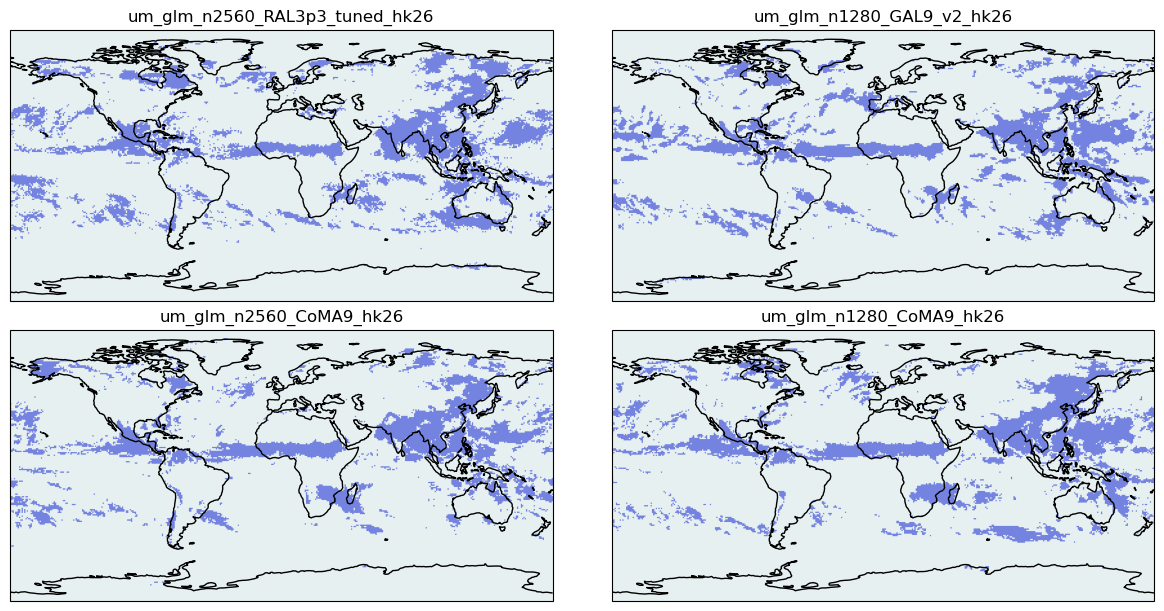

In [22]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [7]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    int(len(sims) / 2),
    figsize=(12,6),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes.ravel().tolist()[sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3)

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr) & restrict_diff(pr),
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")
#         ().plot.contour(ax=ax)

## November & May

In [3]:
def get_proportion(pr, NDJFM=None, MJJAS=None, proportion=0.55, localsummer="lat"):
    if NDJFM == None:
        NDJFM = pr.sel(time=slice("2020-11-01", "2021-03-31")).mean(dim="time")
    if MJJAS == None:
        MJJAS = pr.sel(time=slice("2020-05-01", "2020-09-30")).mean(dim="time")
    
    if localsummer == "lat":
        mjjas_summer = MJJAS.lat > 0
        ndjfm_summer = NDJFM.lat < 0
    elif localsummer=="rain":
        mjjas_summer = (MJJAS - NDJFM) > 0
        ndjfm_summer = (NDJFM - MJJAS) > 0
    annual_sum_ndjfm_summer = pr[:, ndjfm_summer.values].sum(dim="time")
    ndjfm_sum_ndjfm_summer = pr.sel(time=slice("2020-11-01", "2021-03-31")).sum(
        dim="time"
    )
    annual_sum_mjjas_summer = pr[:, mjjas_summer.values].sum(dim="time")
    mjjas_sum_mjjas_summer = pr.sel(time=slice("2020-05-01", "2020-09-30")).sum(
        dim="time"
    )
    annual_sum = pr.sum(dim="time")
    all_sum_local_summer = ndjfm_sum_ndjfm_summer + mjjas_sum_mjjas_summer
    proportion_local_summer = all_sum_local_summer / annual_sum
    return proportion_local_summer

def restrict_proportion(pr, NDJFM=None, MJJAS=None, proportion=0.55):
    proportion_local_summer=get_proportion(pr, NDJFM=NDJFM, MJJAS=MJJAS, proportion=proportion)
    restricted_by_proportion = proportion_local_summer > proportion
    return restricted_by_proportion


def get_diff(pr, NDJFM=None, MJJAS=None, lim=2):
    if NDJFM == None:
        NDJFM = pr.sel(time=slice("2020-11-01", "2021-03-31")).mean(dim="time")
    if MJJAS == None:
        MJJAS = pr.sel(time=slice("2020-05-01", "2020-09-30")).mean(dim="time")
    diff = abs(NDJFM - MJJAS)
    return diff

def restrict_diff(pr, NDJFM=None, MJJAS=None, lim=2):
    diff=get_diff(pr, NDJFM=NDJFM, MJJAS=MJJAS, lim=lim)
    return diff > lim

## UM suites

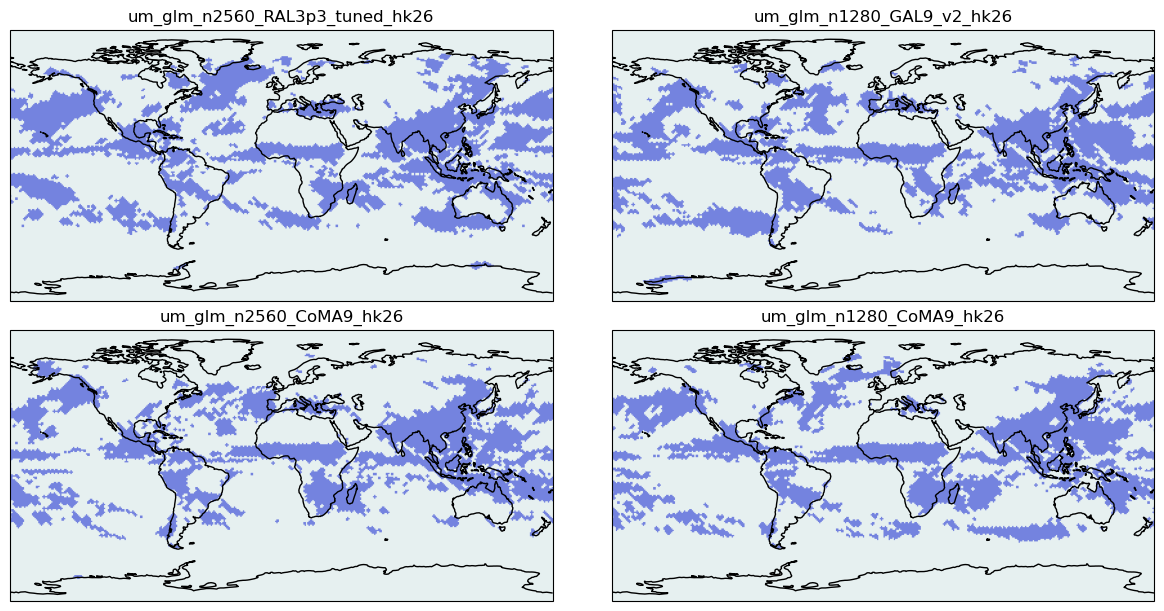

In [16]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [5]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    int(len(sims) / 2),
    figsize=(12, 6),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes.ravel().tolist()[sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3).sel(time=slice("2020-03-01", "2021-02-28"))

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr) & restrict_diff(pr),
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2,
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")
#         ().plot.contour(ax=ax)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


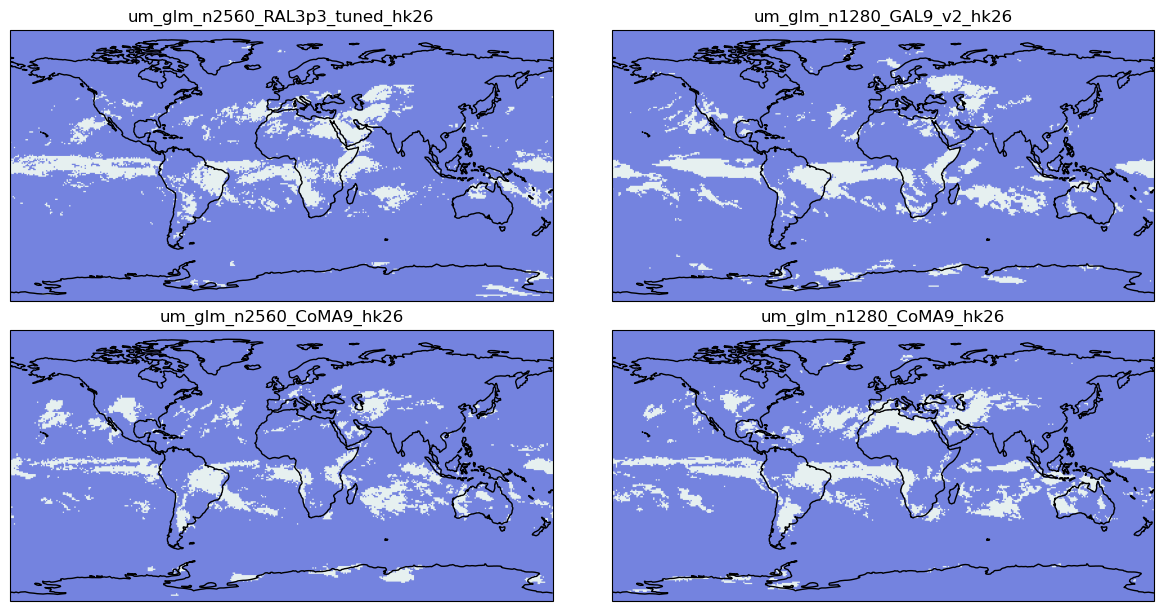

In [13]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [7]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    int(len(sims) / 2),
    figsize=(12,6),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes.ravel().tolist()[sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3)

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr,proportion=0.8),
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")
#         ().plot.contour(ax=ax)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


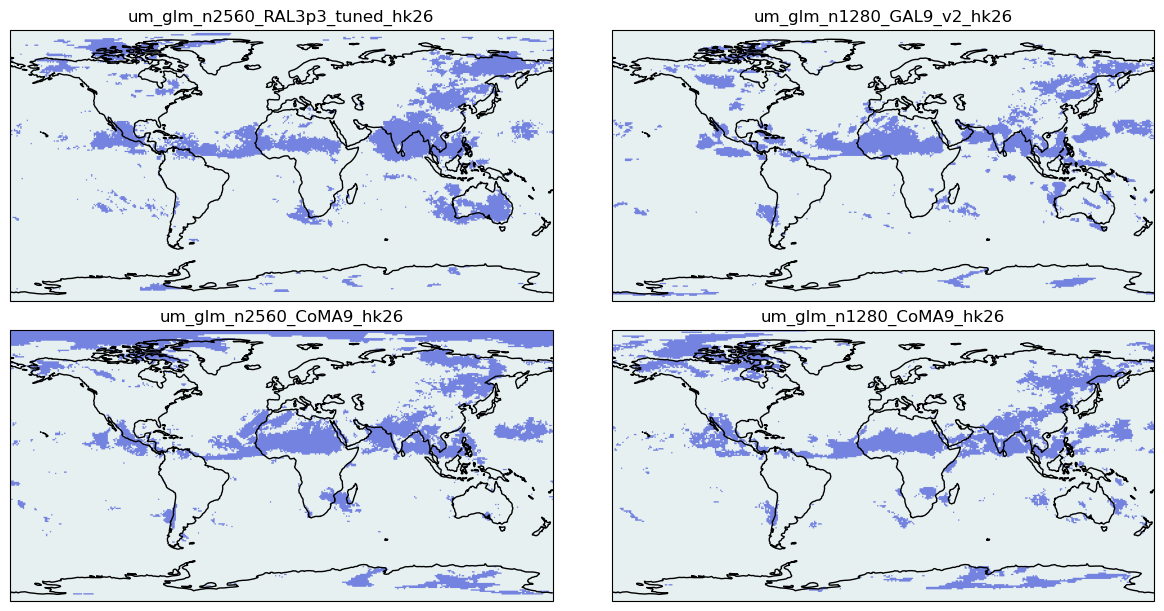

In [15]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "um_glm_n1280_GAL9_v2_hk26",
    "um_glm_n2560_CoMA9_hk26",
    "um_glm_n1280_CoMA9_hk26",
]
zoom = 3
zooms = [7]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    int(len(sims) / 2),
    figsize=(12,6),
    subplot_kw={"projection": projection},
    layout="constrained",
)

for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes.ravel().tolist()[sim_ix]
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds, zoom=3).sel(time=slice("2020-03-01","2021-02-28"))

        pr = ds.pr * 3600 * 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr,proportion=0.8),
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")
#         ().plot.contour(ax=ax)

# More sims

In [4]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "um_glm_n2560_RAL3p3_tuned_hk26",
    "ifs_tco3999-ng5_rcbmf_cf",
    "icon_d3hp003",
    # "casesm2_10km_nocumulus",
    "nicam_gl11",
    # "arp-gem-2p6km",
]
zoom_prime=7
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    2,
    int(len(sims) / 2),
    figsize=(12, 6),
    subplot_kw={"projection": projection},
    layout="constrained",
)


for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    if "IMERG" in sim:
        zooms=[9]
    elif "ifs" in sim:
        zooms=[7]
    elif "arp-gem-2p6km" in sim:
        zooms=[8]
    else:
        zooms=[zoom_prime]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes.ravel().tolist()[sim_ix]
        outdir = f"masks/{sim}_zoom_{zoom}.zarr"
        if os.path.exists(outdir):
            plot = xr.open_dataarray(outdir)
        else:
            print("computing")
            if "hk26" in sim:
                ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods).pr
            else:
                if "icon" in sim or "nicam" in sim:
                    ds = sim_cat(zoom=zoom).to_dask().pipe(egh.attach_coords).pr
                elif "IMERG" in sim:
                    ds = (
                        sim_cat(zoom=9)
                        .to_dask()
                        .pipe(egh.attach_coords)
                        .precipitation
                    )
                elif "arp" in sim:
                    ds = sim_cat(zoom=8).to_dask().pipe(egh.attach_coords).pr
                else:
                    ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(egh.attach_coords).pr
            # ds_latlon = hp_to_latlon(ds, zoom)
            pr = ds.resample(time="1D").mean().sel(time=slice("2020-03-01", "2021-02-28"))
    
            pr *= 3600 * 24
            pr["units"] = "mm day-1"
            plot= restrict_proportion(pr, proportion=0.55) & restrict_diff(pr, lim=2)
            plot.to_zarr(outdir) 
        hp_resampler = HEALPixResampler(nside=egh.get_nside(plot))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            plot,
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2,
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")

        del plot
#         ().plot.contour(ax=ax)

computing


## Obs?

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


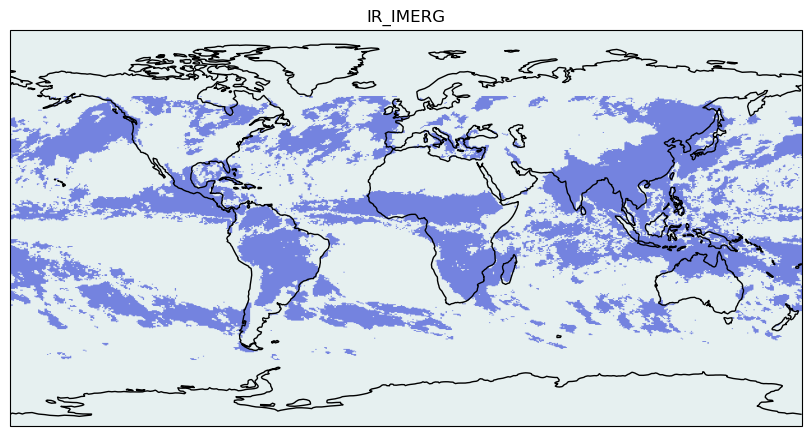

In [15]:
import easygems.show
from easygems.resample import HEALPixResampler
from utils import hp_to_latlon

sims = [
    "IR_IMERG",
]
zoom = 3
zooms = [9]

projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    1,
    figsize=(8, 6),
    subplot_kw={"projection": projection},
    layout="constrained",
)


for sim_ix, sim in enumerate(sims):
    sim_cat = cat[sim]
    for zoom_ix, zoom in enumerate(zooms):
        ax = axes

        if "hk26" in sim:
            ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods).pr
        else:
            if "icon" in sim or "nicam" in sim:
                ds = sim_cat(zoom=zoom).to_dask().pipe(egh.attach_coords).pr
            elif "IMERG" in sim:
                ds = (
                    sim_cat(zoom=zoom)
                    .to_dask()
                    .pipe(egh.attach_coords)
                    .precipitation.sel(time=slice("2020-02-01", "2021-03-31"))
                )

            else:
                ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(egh.attach_coords).pr
        # ds_latlon = hp_to_latlon(ds, zoom)
        pr = ds.resample(time="1D").mean().sel(time=slice("2020-03-01", "2021-02-28"))

        pr *= 24
        pr["units"] = "mm day-1"
        hp_resampler = HEALPixResampler(nside=egh.get_nside(pr))

        ax.set_global()
        ax.coastlines()
        easygems.show.map_show(
            restrict_proportion(pr, proportion=0.55) & restrict_diff(pr, lim=2),
            resampler=hp_resampler,
            ax=ax,
            # alpha=0.4,
            cmap=cmo.cm.dense,
            vmin=0.2,
            vmax=2,
        )
        # easygems.show.map_contour(plot,resampler=hp_resampler,ax=ax)
        ax.set_title(f"{sim}")
#         ().plot.contour(ax=ax)

In [13]:
pr

<xarray.DataArray 'total_precipitation' (time: 365, latitude: 399,
                                         longitude: 1440)> Size: 839MB
array([[[ 7.166011,  4.872859, ...,       nan,       nan],
        [10.467919, 10.435316, ..., 18.719864,  8.037424],
        ...,
        [      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan]],

       [[ 2.012192,  3.023057, ...,       nan,       nan],
        [ 8.308914,  7.009472, ..., 15.272909, 21.457296],
        ...,
        [      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan]],

       ...,

       [[ 0.      ,  0.      , ...,       nan,       nan],
        [ 0.      ,  0.      , ...,  0.      ,  0.      ],
        ...,
        [      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan]],

       [[ 0.      ,  0.      , ...,       nan,       nan],
        [ 0.      ,  0.      , ...,  0.      ,  0.      ],
        ...,
        [      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan]]],
      shape=(365, 399, 1440), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2020-03-01 2020-03-02 ... 2021-02-28
  * latitude   (latitude) float32 2kB 49.75 49.5 49.25 ... -49.25 -49.5 -49.75
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    units:               mm/day
    description:         Daily Precip regridded to ERA5 grid
    time_step:           day
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0
    remap:               remapped via ESMF_regrid_with_weights: First-order C...

Text(0.5, 1.0, 'CHIRPS')

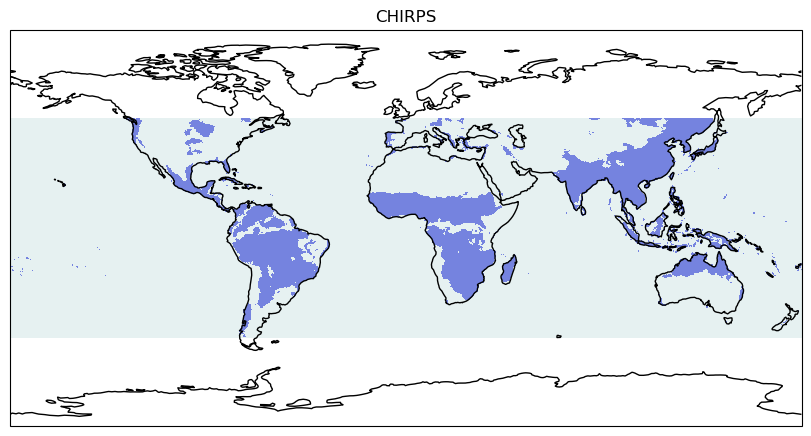

In [16]:
projection = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1,
    1,
    figsize=(8, 6),
    subplot_kw={"projection": projection},
    layout="constrained",
)


ax = axes
pr = xr.open_dataset(
    "/home/users/franmorr/firstrains/OnsetPeriod/data/CHIRPS/CHIRPS_precip.day.total_1981-2024.025dg.aw.nc"
).total_precipitation.sel(time=slice("2020-03-01", "2021-02-28"))
pr = pr.rename({"latitude": "lat", "longitude": "lon"})
ax.set_global()
ax.coastlines()
monsoon_area = (restrict_proportion(pr, proportion=0.55) & restrict_diff(pr, lim=2),)

monsoon_area[0].plot(
    ax=ax,
    add_colorbar=False,
    cmap=cmo.cm.dense,
    vmin=0.2,
    vmax=2,
)
ax.set_title(f"CHIRPS")

In [8]:
monsoon_area

(<xarray.DataArray 'total_precipitation' (lat: 399, lon: 1440)> Size: 575kB
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(399, 1440))
 Coordinates:
   * lat      (lat) float32 2kB 49.75 49.5 49.25 49.0 ... -49.25 -49.5 -49.75
   * lon      (lon) float32 6kB 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
 Attributes:
     standard_name:       convective precipitation rate
     long_name:           Climate Hazards group InfraRed Precipitation with St...
     units:               mm/day
     description:         Daily Precip regridded to ERA5 grid
     time_step:           day
     geostatial_lat_min:  -50.0
     geostatial_lat_max:  50.0
     geostatial_lon_min:  -180.0
   